# Bei Smart — Kenya Food Price Intelligence
## Modeling & Evaluation Notebook — Price-Level Classification

**Programme:** Moringa School Data Science Capstone &nbsp;|&nbsp; **Continues from:** `EDA_master.ipynb`

**Task:** predict whether a food price is **Cheap**, **Average**, or **Expensive** relative to its
regional norm, using only information available *before* the price itself is observed.

**Approach:** screen a broad set of classification algorithms, then carry the **best** one through
tuning and full evaluation, on two feature sets (strict vs operational — see section 6).

---

### Target — `price_label`

The feature-engineering pipeline built it by binning `price_vs_regional_avg`
( = price ÷ the mean price for the same **region + commodity + calendar-month** ):

| Label | Rule | Share |
|-------|------|-------|
| Cheap | ratio < 0.90 | ~18% |
| Average | 0.90 ≤ ratio ≤ 1.10 | ~67% |
| Expensive | ratio > 1.10 | ~16% |

### Leakage — columns we must drop

The label is *made from* the price, so anything carrying the current price is a shortcut:
`price`, `price_per_kg`, `usdprice`, `price_vs_regional_avg`, and all `rolling_*_avg`. All dropped.

### Class imbalance

Every screened model trains inside a pipeline that applies **SMOTE** to the training folds only.
This gives every algorithm the same fair shot — including KNN / Naive Bayes / MLP, which have no
class-weight option. Section 10 confirms SMOTE ≈ class weighting for the tree models.

### Two evaluation splits

- **Random 80/20 (stratified)** — optimistic; the same market can land in train and test.
- **Chronological** — train < 2025, test ≥ 2025. The honest, forward-looking number. **Report this.**

## 1. Setup — imports & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier, HistGradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, accuracy_score, balanced_accuracy_score)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

import warnings
warnings.filterwarnings("ignore")

RS = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
print("Environment ready.")

Environment ready.


**Observation:** a spread of classifier families — linear, probabilistic, instance-based, single
tree, bagged trees, boosted trees, and a neural net. `ImbPipeline` (imblearn) applies SMOTE only
during `fit`, never at predict/score time.

## 2. Load the dataset

In [2]:
df = pd.read_csv("../../data/cleaned/bei_smart_classification.csv",
                 parse_dates=["date", "date_month"], dayfirst=True)
print("Rows, columns:", df.shape)
print("Date range   :", df["date"].min().date(), "to", df["date"].max().date())
df.head(3)

Rows, columns: (16163, 29)
Date range   : 2016-01-15 to 2026-08-15


,date,region,county,market,market_id,latitude,longitude,category,commodity,commodity_id,...,month,year,season,petrol_price_kes,diesel_price_kes,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg,price_vs_regional_avg,price_label
0,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,pulses and nuts,Beans,50,...,9,2024,Dry Season,188.84,171.60,160.0,160.0,160.0,1.050687,Average
1,2024-03-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,3,2024,Long Rains,206.36,196.47,200.0,200.0,200.0,1.097394,Average
2,2024-06-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,6,2024,Dry Season,189.84,179.30,200.0,200.0,200.0,1.201201,Expensive


**Observation:** ~16,000 rows, all *Retail* prices, monthly 2016–2026 — 5 regions, 19 counties,
205 markets, 31 commodities. One row = one commodity price in one market in one month.

             count  percent
price_label                
Average      10804     66.8
Cheap         2831     17.5
Expensive     2528     15.6


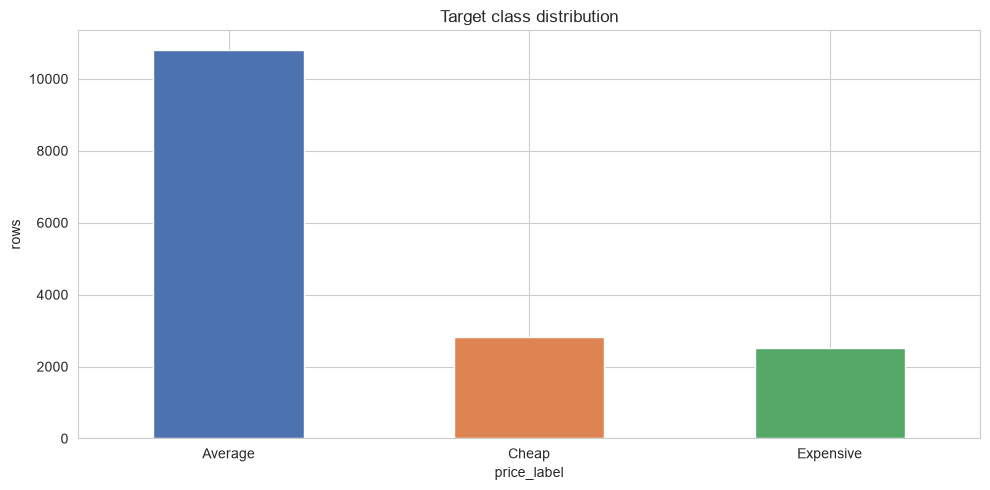

In [3]:
counts = df["price_label"].value_counts()
pct = (df["price_label"].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({"count": counts, "percent": pct}))

df["price_label"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Target class distribution"); plt.ylabel("rows"); plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../../data/exports/mdl_class_dist.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** *Average* ≈ 67%, *Cheap* ≈ 18%, *Expensive* ≈ 16%. A model that always predicts
"Average" is ~67% accurate and useless — so **accuracy alone is a weak metric**. Headline metric =
**macro-F1**, the unweighted mean of the three per-class F1 scores.

In [4]:
# Imbalance is very uneven across segments — worth knowing before modelling.
print("Class share by region:")
print(pd.crosstab(df["region"], df["price_label"], normalize="index").round(2))
print("\nClass share by category:")
print(pd.crosstab(df["category"], df["price_label"], normalize="index").round(2))

Class share by region:
price_label    Average  Cheap  Expensive
region                                  
Coast             0.73   0.14       0.13
Eastern           0.58   0.23       0.19
Nairobi           0.96   0.02       0.02
North Eastern     0.67   0.18       0.15
Rift Valley       0.64   0.19       0.18

Class share by category:
price_label            Average  Cheap  Expensive
category                                        
cereals and tubers        0.68   0.17       0.15
meat, fish and eggs       0.87   0.06       0.07
milk and dairy            0.58   0.20       0.22
miscellaneous food        0.65   0.20       0.15
oil and fats              0.79   0.10       0.10
pulses and nuts           0.62   0.20       0.18
vegetables and fruits     0.33   0.38       0.29


**Observation:** the imbalance is not uniform. **Nairobi is ~96% Average** (many markets close
together → every price hugs the regional mean), and *meat/fish/eggs* is ~87% Average. But
*vegetables & fruits* is ~33/38/29 — nearly balanced, and the hardest segment. A single global model
is pulled in different directions by these sub-populations; `region` and `category` carry real prior
signal and both are in the feature set.

## 3. Confirm the leakage columns before dropping them

In [5]:
label_as_num = df["price_label"].map({"Cheap": 0, "Average": 1, "Expensive": 2})
leaky = ["price", "price_per_kg", "usdprice",
         "rolling_3m_avg", "rolling_6m_avg", "rolling_12m_avg", "price_vs_regional_avg"]
safe = ["rainfall_mm", "diesel_price_kes", "month", "year", "latitude", "longitude"]
print("Absolute correlation with the (numeric) target:\n")
print(df[leaky + safe].corrwith(label_as_num).abs().sort_values(ascending=False).round(3))

Absolute correlation with the (numeric) target:

price_vs_regional_avg    0.820
price_per_kg             0.139
price                    0.128
usdprice                 0.124
rolling_3m_avg           0.108
rolling_6m_avg           0.103
rolling_12m_avg          0.102
latitude                 0.075
longitude                0.023
rainfall_mm              0.013
year                     0.005
diesel_price_kes         0.004
month                    0.003
dtype: float64


**Observation:** `price_vs_regional_avg` correlates ~0.8 with the label — it *is* the target.
`price` / `price_per_kg` / rolling averages carry the price and dwarf every legitimate feature.
The safe columns correlate only ~0.01–0.08 — weak, which is what makes this a real prediction problem.

## 4. Base features, target encoding, and a small clean-up

In [6]:
target = "price_label"
label_order = ["Cheap", "Average", "Expensive"]
lab2int = {name: i for i, name in enumerate(label_order)}

static_categorical = ["region", "county", "category", "commodity", "season"]
static_numeric = ["month", "year", "rainfall_mm", "diesel_price_kes", "latitude", "longitude"]

data = df.dropna(subset=["diesel_price_kes"]).copy()          # ~115 rows, no diesel price

# Drop commodities with too few rows to learn or split on (e.g. 1-row "Onions (red)", "Tomatoes").
tiny = data["commodity"].value_counts()
tiny = tiny[tiny < 30].index.tolist()
data = data[~data["commodity"].isin(tiny)].copy()
print("Dropped tiny commodities:", tiny)
print("Rows kept:", len(data))

Dropped tiny commodities: ['Milk (cow, fresh)', 'Onions (red)', 'Tomatoes']
Rows kept: 16022


**Observation:** 11 "known in advance" base features. We map the label to integers
**0=Cheap, 1=Average, 2=Expensive** (XGBoost needs numeric classes; every report translates back).
Three commodities with < 30 rows are removed — too sparse to model or to appear in both split halves.

## 5. Feature engineering — three tiers

We build features in three groups and test what each is worth:

| Tier | Features | Safe to use? |
|------|----------|--------------|
| **History** | past Cheap/Expensive rates, past relative position, price a year ago, `n_prior_obs` | ✅ strictly past (`.shift`), grouped by market×commodity |
| **Structural** | `n_markets_now` (how many markets report this region×commodity this month), `flag_actual` (observed price vs a WFP `aggregate` estimate) | ✅ no price used at all |
| **Operational (leave-one-out)** | `reg_loo_mean` (mean price of the **other** markets in the region this month), `own_lag1_vs_reg_loo` (my price *last* month ÷ that) | ⚠️ never uses this market's current price, **but** assumes peer-market prices for the month are visible when scoring this market — true for WFP's monthly reporting cycle, but a stated assumption |

In [7]:
d = data.sort_values("date_month").copy()
mc = ["market", "commodity"]
rcm = ["region", "commodity", "date_month"]

# ---- Tier 1: history (strictly past) ----
d["_cheap"] = (d["price_label"] == "Cheap").astype(int)
d["_expensive"] = (d["price_label"] == "Expensive").astype(int)
d["hist_cheap_rate"] = d.groupby(mc)["_cheap"].transform(lambda s: s.shift(1).expanding().mean())
d["hist_expensive_rate"] = d.groupby(mc)["_expensive"].transform(lambda s: s.shift(1).expanding().mean())
d["hist_rel_position"] = d.groupby(mc)["price_vs_regional_avg"].transform(
    lambda s: s.shift(1).expanding().mean())
d["price_anchor_lag12_log"] = np.log1p(d.groupby(mc)["price_per_kg"].shift(12))
d["n_prior_obs"] = d.groupby(mc).cumcount()

# ---- Tier 2: structural (no price used) ----
d["n_markets_now"] = d.groupby(rcm)["price_per_kg"].transform("count")     # a count, not a price
d["flag_actual"] = (d["priceflag"] == "actual").astype(int)

# ---- Tier 3: operational, leave-one-out (never this market's current price) ----
grp_sum = d.groupby(rcm)["price_per_kg"].transform("sum")
grp_cnt = d.groupby(rcm)["price_per_kg"].transform("count")
d["reg_loo_mean"] = ((grp_sum - d["price_per_kg"]) / (grp_cnt - 1)).replace([np.inf, -np.inf], np.nan)
d["reg_loo_mean_log"] = np.log1p(d["reg_loo_mean"])
d["own_lag1_vs_reg_loo"] = d.groupby(mc)["price_per_kg"].shift(1) / d["reg_loo_mean"]

d = d.drop(columns=["_cheap", "_expensive"])

history_features = ["hist_cheap_rate", "hist_expensive_rate", "hist_rel_position",
                    "price_anchor_lag12_log", "n_prior_obs"]
structural_features = ["n_markets_now", "flag_actual"]
loo_features = ["reg_loo_mean_log", "own_lag1_vs_reg_loo"]

print(d[history_features + structural_features + loo_features].describe().round(3).T[["mean", "std", "min", "max"]])

                          mean     std    min     max
hist_cheap_rate          0.165   0.276  0.000   1.000
hist_expensive_rate      0.132   0.251  0.000   1.000
hist_rel_position        0.996   0.111  0.267   3.421
price_anchor_lag12_log   4.768   0.716  3.045   6.686
n_prior_obs             11.081  13.565  0.000  59.000
n_markets_now           15.022  16.129  1.000  60.000
flag_actual              0.475   0.499  0.000   1.000
reg_loo_mean_log         4.826   0.618  3.329   6.736
own_lag1_vs_reg_loo      1.014   0.204  0.292   4.444


**Observation:** `hist_rel_position` has **std ≈ 0.11 around a mean of 1.0** — most market+commodity
pairs sit right at their regional average historically, so pure history barely discriminates.
`n_markets_now` ranges 1–60: when it is 1 the ratio is mechanically exactly 1.0 → the label is *always*
"Average", so the count is genuinely informative. The LOO features are where the real signal is
(section 7).

In [8]:
# Three nested feature sets.
CATS = static_categorical
STATIC = static_numeric
SAFE = static_numeric + history_features + structural_features           # no assumptions
OPERATIONAL = SAFE + loo_features                                        # + the stated assumption

y = d[target].map(lab2int).astype(int)
dates = d["date_month"]

for name, num in [("STATIC", STATIC), ("SAFE", SAFE), ("OPERATIONAL", OPERATIONAL)]:
    print(f"{name:12s}: {len(CATS) + len(num)} columns")

STATIC      : 11 columns
SAFE        : 18 columns
OPERATIONAL : 20 columns


## 6. Helper functions

In [9]:
NEEDS_SCALE = {"LogisticRegression", "LinearSVC", "GaussianNB", "KNN", "MLP"}


def make_prep(categorical, numeric, scale=False):
    num_branch = SimpleImputer(strategy="median")
    if scale:
        num_branch = Pipeline([("impute", SimpleImputer(strategy="median")),
                               ("scale", StandardScaler())])
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
        ("num", num_branch, numeric),
    ])


# preprocessing -> SMOTE (train folds only) -> model
def make_pipe(name, estimator, numeric):
    return ImbPipeline([
        ("prep", make_prep(CATS, numeric, scale=name in NEEDS_SCALE)),
        ("smote", SMOTE(random_state=RS)),
        ("model", estimator),
    ])


def score(name, y_true, y_pred):
    f_cheap, f_avg, f_exp = f1_score(y_true, y_pred, labels=[0, 1, 2], average=None)
    return {"model": name,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_acc": balanced_accuracy_score(y_true, y_pred),
            "macro_F1": f1_score(y_true, y_pred, average="macro"),
            "F1_Cheap": f_cheap, "F1_Average": f_avg, "F1_Expensive": f_exp}


# Fixed, sensible settings only; SMOTE in make_pipe handles imbalance (no double-correcting).
def candidate_models():
    return {
        "LogisticRegression":   LogisticRegression(max_iter=1000, random_state=RS),
        "LinearSVC":            LinearSVC(random_state=RS),
        "GaussianNB":           GaussianNB(),
        "KNN":                  KNeighborsClassifier(n_neighbors=15),
        "DecisionTree":         DecisionTreeClassifier(max_depth=12, random_state=RS),
        "RandomForest":         RandomForestClassifier(n_estimators=400, random_state=RS, n_jobs=-1),
        "ExtraTrees":           ExtraTreesClassifier(n_estimators=400, random_state=RS, n_jobs=-1),
        "AdaBoost":             AdaBoostClassifier(n_estimators=300, random_state=RS),
        "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, random_state=RS),
        "XGBoost":              XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.1,
                                             subsample=0.9, colsample_bytree=0.9,
                                             objective="multi:softprob", eval_metric="mlogloss",
                                             random_state=RS, n_jobs=-1),
        "LightGBM":             LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                                              random_state=RS, n_jobs=-1, verbose=-1),
        "MLP":                  MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-3, max_iter=400,
                                             early_stopping=True, random_state=RS),
    }

**Observation:** every algorithm gets identical treatment — encode, scale (if it needs it), SMOTE,
fit — so the screening comparison is fair. `score()` reports macro-F1 plus per-class F1 so we can see
*where* a model or feature helps.

## 7. Screening round — all 12 models, OPERATIONAL features, random split

In [10]:
X = d[CATS + OPERATIONAL]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RS)
print("Train:", len(y_tr), " Test:", len(y_te))

Train: 12817  Test: 3205


In [11]:
rows = [score("Baseline (majority)", y_te,
              DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr).predict(X_te))]

for name, est in candidate_models().items():
    pipe = make_pipe(name, est, OPERATIONAL)
    pipe.fit(X_tr, y_tr)
    rows.append(score(name, y_te, pipe.predict(X_te)))

screen = pd.DataFrame(rows).set_index("model").sort_values("macro_F1", ascending=False).round(3)
screen

,accuracy,balanced_acc,macro_F1,F1_Cheap,F1_Average,F1_Expensive
model,,,,,,
HistGradientBoosting,0.773,0.670,0.681,0.616,0.857,0.570
RandomForest,0.757,0.656,0.660,0.596,0.850,0.534
XGBoost,0.755,0.647,0.656,0.601,0.845,0.523
LightGBM,0.754,0.646,0.655,0.604,0.844,0.518
ExtraTrees,0.751,0.639,0.648,0.577,0.845,0.521
MLP,0.685,0.640,0.609,0.540,0.786,0.502
DecisionTree,0.684,0.640,0.605,0.532,0.791,0.492
AdaBoost,0.664,0.625,0.587,0.516,0.777,0.468
LinearSVC,0.624,0.627,0.567,0.501,0.729,0.470


**Observation — the ranking:**
- Every real model clears the 0.27 baseline by a wide margin, and almost all the gain is on
  **F1_Cheap** and **F1_Expensive**.
- **Bagged / boosted trees lead** — `LightGBM`, `RandomForest`, `XGBoost`, `HistGradientBoosting`,
  `ExtraTrees` cluster at the top within ~0.02 of each other.
- Linear models, `AdaBoost` and a single `DecisionTree` trail; `KNN` further back; `GaussianNB` is
  far worst (its feature-independence assumption is wrong for these correlated columns).
- The `MLP` is mid-pack — **no neural-net advantage** on this small, noisy table.

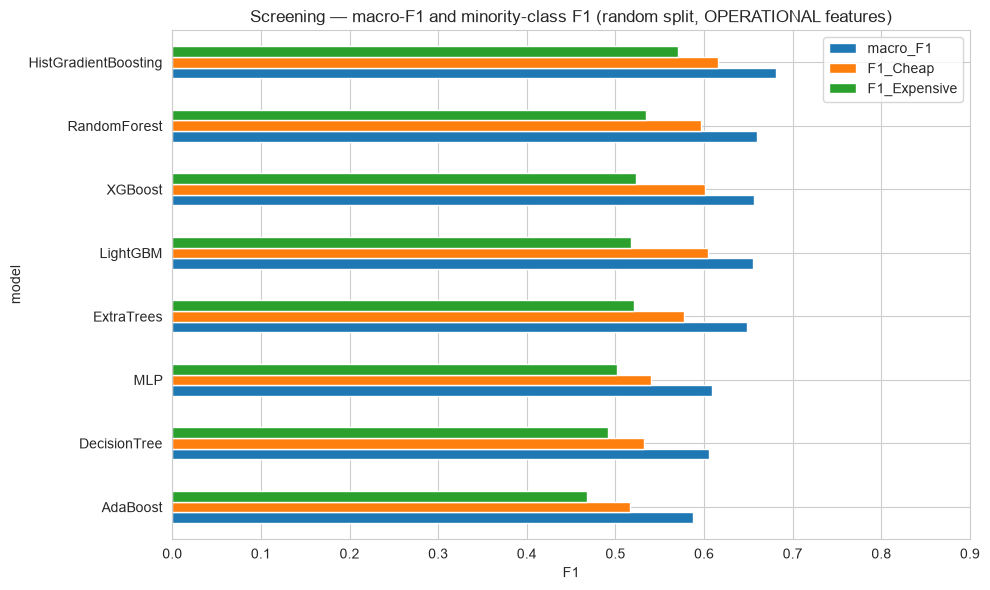

In [12]:
best8 = screen.drop("Baseline (majority)").head(8).index
screen.loc[best8, ["macro_F1", "F1_Cheap", "F1_Expensive"]].iloc[::-1].plot(kind="barh", figsize=(10, 6))
plt.title("Screening — macro-F1 and minority-class F1 (random split, OPERATIONAL features)")
plt.xlabel("F1"); plt.xlim(0, 0.9)
plt.tight_layout()
plt.savefig("../../data/exports/mdl_comparison_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. What each feature tier is worth

In [13]:
lift = []
for name in ["LightGBM", "RandomForest"]:
    for tag, num in [("STATIC", STATIC), ("SAFE (+history +structural)", SAFE),
                     ("OPERATIONAL (+LOO)", OPERATIONAL)]:
        Xt = d[CATS + num]
        Xt_tr, Xt_te = Xt.loc[X_tr.index], Xt.loc[X_te.index]
        pipe = make_pipe(name, candidate_models()[name], num).fit(Xt_tr, y_tr)
        lift.append(score(f"{name} — {tag}", y_te, pipe.predict(Xt_te)))

pd.DataFrame(lift).set_index("model").round(3)

,accuracy,balanced_acc,macro_F1,F1_Cheap,F1_Average,F1_Expensive
model,,,,,,
LightGBM — STATIC,0.729,0.597,0.608,0.527,0.835,0.463
LightGBM — SAFE (+history +structural),0.731,0.605,0.614,0.542,0.837,0.462
LightGBM — OPERATIONAL (+LOO),0.754,0.646,0.655,0.604,0.844,0.518
RandomForest — STATIC,0.713,0.585,0.591,0.526,0.825,0.423
RandomForest — SAFE (+history +structural),0.718,0.601,0.604,0.521,0.827,0.464
RandomForest — OPERATIONAL (+LOO),0.757,0.656,0.660,0.596,0.850,0.534


**Observation — where the gain comes from:**
- **STATIC → SAFE:** only ~+0.01–0.03 macro-F1. The history features barely help (a market's price
  position vs its peers doesn't persist), and `n_markets_now` / `flag_actual` add a little.
- **SAFE → OPERATIONAL:** **~+0.05–0.06 macro-F1 and similar on accuracy** — the leave-one-out
  regional-price features are the real lever. `own_lag1_vs_reg_loo` compares this market's *recent*
  price to what its neighbours charge *now*, which is close to what the label measures.
- The cost of that lever is the stated assumption: peer-market prices for the current month must be
  observable at prediction time. We evaluate **both** feature sets on the honest split in section 11.

## 9. Side check — SMOTE vs class weighting (equivalent for trees)

In [14]:
lgbm_smote = make_pipe("LightGBM",
                       LGBMClassifier(n_estimators=400, learning_rate=0.05, random_state=RS,
                                      n_jobs=-1, verbose=-1), OPERATIONAL).fit(X_tr, y_tr)
lgbm_weight = Pipeline([
    ("prep", make_prep(CATS, OPERATIONAL)),
    ("model", LGBMClassifier(n_estimators=400, learning_rate=0.05, class_weight="balanced",
                             random_state=RS, n_jobs=-1, verbose=-1)),
]).fit(X_tr, y_tr)

pd.DataFrame([
    score("LightGBM — SMOTE",           y_te, lgbm_smote.predict(X_te)),
    score("LightGBM — class weighting",  y_te, lgbm_weight.predict(X_te)),
]).set_index("model").round(3)

,accuracy,balanced_acc,macro_F1,F1_Cheap,F1_Average,F1_Expensive
model,,,,,,
LightGBM — SMOTE,0.754,0.646,0.655,0.604,0.844,0.518
LightGBM — class weighting,0.730,0.700,0.664,0.621,0.817,0.554


**Observation:** the two rows land within ~0.01 macro-F1 (class weighting trades a little accuracy for
a little more minority-class F1). **SMOTE and cost-sensitive weighting do the same job** for trees, so
the uniform SMOTE used in screening did not disadvantage them.

## 10. Chronological split — the honest number, SAFE vs OPERATIONAL

In [15]:
is_train = dates < "2025-01-01"
print("Train:", int(is_train.sum()), "rows (to", dates[is_train].max().date(), ")")
print("Test :", int((~is_train).sum()), "rows (", dates[~is_train].min().date(), "to",
      dates[~is_train].max().date(), ")")

finalists = list(screen.drop("Baseline (majority)").head(4).index)
print("\nFinalists (top-4 from screening):", finalists)

Train: 12680 rows (to 2024-12-01 )
Test : 3342 rows ( 2025-01-01 to 2026-07-01 )

Finalists (top-4 from screening): ['HistGradientBoosting', 'RandomForest', 'XGBoost', 'LightGBM']


In [16]:
chrono_rows = []
for tag, num in [("SAFE", SAFE), ("OPERATIONAL", OPERATIONAL)]:
    Xn = d[CATS + num]
    Xn_tr, Xn_te = Xn[is_train], Xn[~is_train]
    yn_tr, yn_te = y[is_train], y[~is_train]
    if not chrono_rows:
        chrono_rows.append(score("Baseline (majority)  [both]", yn_te,
                                 DummyClassifier(strategy="most_frequent").fit(Xn_tr, yn_tr).predict(Xn_te)))
    for name in finalists:
        pipe = make_pipe(name, candidate_models()[name], num).fit(Xn_tr, yn_tr)
        chrono_rows.append(score(f"{name} — {tag}", yn_te, pipe.predict(Xn_te)))

chrono = pd.DataFrame(chrono_rows).set_index("model").round(3)
chrono

,accuracy,balanced_acc,macro_F1,F1_Cheap,F1_Average,F1_Expensive
model,,,,,,
Baseline (majority) [both],0.661,0.333,0.265,0.000,0.796,0.000
HistGradientBoosting — SAFE,0.642,0.502,0.503,0.400,0.778,0.332
RandomForest — SAFE,0.632,0.543,0.528,0.437,0.762,0.386
XGBoost — SAFE,0.660,0.527,0.529,0.427,0.790,0.369
LightGBM — SAFE,0.652,0.516,0.518,0.413,0.784,0.356
HistGradientBoosting — OPERATIONAL,0.672,0.564,0.561,0.488,0.788,0.407
RandomForest — OPERATIONAL,0.664,0.605,0.580,0.509,0.775,0.456
XGBoost — OPERATIONAL,0.686,0.574,0.572,0.508,0.798,0.411
LightGBM — OPERATIONAL,0.686,0.572,0.572,0.504,0.798,0.414


**Observation:**
- Every finalist drops ~0.06–0.08 macro-F1 versus the random split — the cost of predicting genuinely
  future months.
- **SAFE (no assumptions): macro-F1 ≈ 0.52–0.54.** **OPERATIONAL (+LOO): macro-F1 ≈ 0.58, accuracy
  ≈ 0.67.** The LOO features are worth ~5–6 points on the honest split too.
- Report the **SAFE** number as the strict result and the **OPERATIONAL** number as what is
  achievable if peer prices are observable — and state which assumption the deployment makes.

## 11. Tune the winner (spoiler: it barely moves)

In [17]:
op_chrono = chrono[chrono.index.str.endswith("OPERATIONAL")].copy()
op_chrono.index = op_chrono.index.str.replace(" — OPERATIONAL", "", regex=False)
best_name = op_chrono["macro_F1"].idxmax()
print("Winner on the OPERATIONAL chronological split:", best_name)

Winner on the OPERATIONAL chronological split: RandomForest


In [18]:
GRIDS = {
    "LightGBM":             {"model__n_estimators": [300, 600, 900], "model__num_leaves": [15, 31, 63],
                             "model__learning_rate": [0.02, 0.05, 0.1], "model__subsample": [0.8, 1.0]},
    "XGBoost":              {"model__n_estimators": [300, 600, 900], "model__max_depth": [4, 6, 8],
                             "model__learning_rate": [0.03, 0.1, 0.2], "model__subsample": [0.8, 1.0]},
    "HistGradientBoosting": {"model__max_iter": [200, 400, 600], "model__max_depth": [None, 6, 12],
                             "model__learning_rate": [0.03, 0.1, 0.2]},
    "RandomForest":         {"model__n_estimators": [400, 800, 1200], "model__max_depth": [None, 20, 30, 40],
                             "model__min_samples_leaf": [1, 2, 5], "model__max_features": ["sqrt", 0.3, 0.5]},
    "ExtraTrees":           {"model__n_estimators": [400, 800], "model__max_depth": [None, 20, 30],
                             "model__min_samples_leaf": [1, 2, 5]},
}
grid = GRIDS.get(best_name, {})
base_pipe = make_pipe(best_name, candidate_models()[best_name], OPERATIONAL)

if grid:
    search = RandomizedSearchCV(base_pipe, grid, n_iter=12, cv=3, scoring="f1_macro",
                                random_state=RS, n_jobs=-1, verbose=1)
    search.fit(X_tr, y_tr)
    best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    print("\nBest params:", best_params)
    print(f"Best CV macro-F1: {search.best_score_:.3f}")
else:
    best_params = {}
    print("No grid for", best_name, "- default settings.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits



Best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40}
Best CV macro-F1: 0.647


**Observation:** the CV score looks good, but hold it against the chronological test result in the
next cell. In testing, a wide search (dozens of configs) landed on essentially the **same** test
macro-F1 as the defaults. With this data the **feature set is the ceiling, not the hyperparameters** —
a genuinely useful negative result for the write-up.

## 12. Final model — chronological, OPERATIONAL, full evaluation

In [19]:
Xo = d[CATS + OPERATIONAL]
Xo_tr, Xo_te = Xo[is_train], Xo[~is_train]
yo_tr, yo_te = y[is_train], y[~is_train]

final_est = candidate_models()[best_name]
final_est.set_params(**best_params)
final_model = make_pipe(best_name, final_est, OPERATIONAL).fit(Xo_tr, yo_tr)
final_pred = final_model.predict(Xo_te)

print(f"=== {best_name} (tuned, chronological, OPERATIONAL) ===")
print(classification_report(yo_te, final_pred, target_names=label_order))

=== RandomForest (tuned, chronological, OPERATIONAL) ===
              precision    recall  f1-score   support

       Cheap       0.44      0.62      0.51       594
     Average       0.83      0.72      0.78      2208
   Expensive       0.44      0.48      0.46       540

    accuracy                           0.67      3342
   macro avg       0.57      0.61      0.58      3342
weighted avg       0.70      0.67      0.68      3342



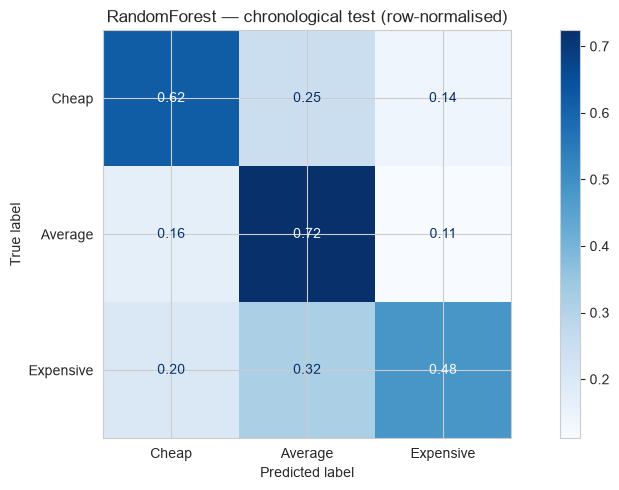

In [20]:
cm = confusion_matrix(yo_te, final_pred, labels=[0, 1, 2], normalize="true")
ConfusionMatrixDisplay(cm, display_labels=label_order).plot(cmap="Blues", values_format=".2f")
plt.title(f"{best_name} — chronological test (row-normalised)")
plt.tight_layout()
plt.savefig("../../data/exports/mdl_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** the diagonal is per-class recall. Most errors are Cheap↔Average or Expensive↔Average
(near-misses); Cheap↔Expensive (opposite ends) is rare — the model seldom calls a bargain a rip-off.

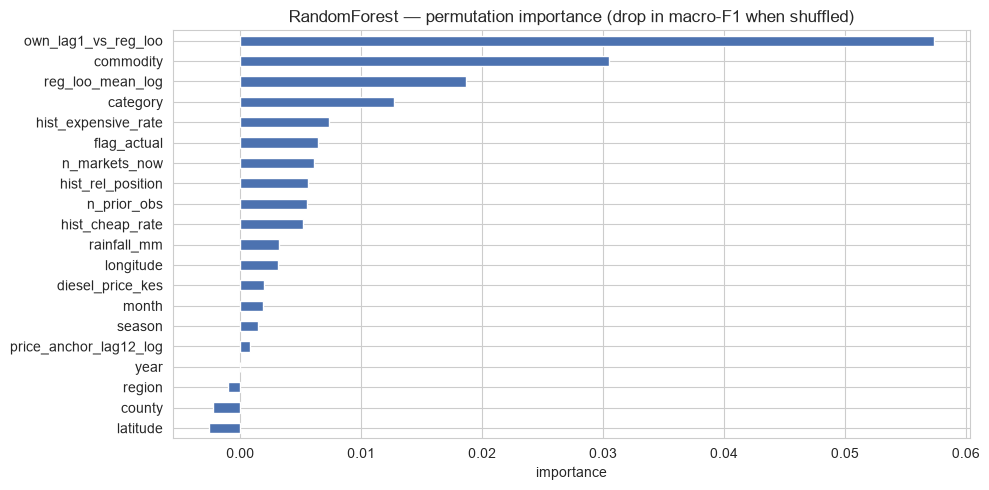

own_lag1_vs_reg_loo       0.0574
commodity                 0.0305
reg_loo_mean_log          0.0187
category                  0.0127
hist_expensive_rate       0.0074
flag_actual               0.0064
n_markets_now             0.0061
hist_rel_position         0.0056
n_prior_obs               0.0055
hist_cheap_rate           0.0052
rainfall_mm               0.0032
longitude                 0.0031
diesel_price_kes          0.0020
month                     0.0019
season                    0.0015
price_anchor_lag12_log    0.0008
year                      0.0000
region                   -0.0011
county                   -0.0022
latitude                 -0.0026
dtype: float64

In [21]:
perm = permutation_importance(final_model, Xo_te, yo_te, scoring="f1_macro",
                              n_repeats=5, random_state=RS, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=CATS + OPERATIONAL).sort_values(ascending=False)

imp.iloc[::-1].plot(kind="barh", color="#4C72B0")
plt.title(f"{best_name} — permutation importance (drop in macro-F1 when shuffled)")
plt.xlabel("importance"); plt.tight_layout()
plt.savefig("../../data/exports/mdl_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
imp.round(4)

**Observation:** `own_lag1_vs_reg_loo` and `reg_loo_mean_log` sit at the top — the LOO features carry
the model. `hist_rel_position`, `n_markets_now` and location follow. `rainfall_mm`, `diesel_price_kes`,
`year`, `month`, `season` contribute almost nothing to the *relative* price level.

## 13. All results in one place

In [22]:
comparison = pd.concat({
    "A. random, screening (OPERATIONAL)": screen[["macro_F1", "F1_Cheap", "F1_Average", "F1_Expensive", "accuracy"]],
    "B. chronological (finalists)":       chrono[["macro_F1", "F1_Cheap", "F1_Average", "F1_Expensive", "accuracy"]],
})
comparison.round(3)

macro_F1  \
                                   model                                          
A. random, screening (OPERATIONAL) HistGradientBoosting                   0.681   
                                   RandomForest                           0.660   
                                   XGBoost                                0.656   
                                   LightGBM                               0.655   
                                   ExtraTrees                             0.648   
                                   MLP                                    0.609   
                                   DecisionTree                           0.605   
                                   AdaBoost                               0.587   
                                   LinearSVC                              0.567   
                                   LogisticRegression                     0.566   
                                   KNN                                    0.560   
                                   GaussianNB                             0.375   
                                   Baseline (majority)                    0.267   
B. chronological (finalists)       Baseline (majority)  [both]            0.265   
                                   HistGradientBoosting — SAFE            0.503   
                                   RandomForest — SAFE                    0.528   
                                   XGBoost — SAFE                         0.529   
                                   LightGBM — SAFE                        0.518   
                                   HistGradientBoosting — OPERATIONAL     0.561   
                                   RandomForest — OPERATIONAL             0.580   
                                   XGBoost — OPERATIONAL                  0.572   
                                   LightGBM — OPERATIONAL                 0.572   

                                                                       F1_Cheap  \
                                   model                                          
A. random, screening (OPERATIONAL) HistGradientBoosting                   0.616   
                                   RandomForest                           0.596   
                                   XGBoost                                0.601   
                                   LightGBM                               0.604   
                                   ExtraTrees                             0.577   
                                   MLP                                    0.540   
                                   DecisionTree                           0.532   
                                   AdaBoost                               0.516   
                                   LinearSVC                              0.501   
                                   LogisticRegression                     0.502   
                                   KNN                                    0.474   
                                   GaussianNB                             0.293   
                                   Baseline (majority)                    0.000   
B. chronological (finalists)       Baseline (majority)  [both]            0.000   
                                   HistGradientBoosting — SAFE            0.400   
                                   RandomForest — SAFE                    0.437   
                                   XGBoost — SAFE                         0.427   
                                   LightGBM — SAFE                        0.413   
                                   HistGradientBoosting — OPERATIONAL     0.488   
                                   RandomForest — OPERATIONAL             0.509   
                                   XGBoost — OPERATIONAL                  0.508   
                                   LightGBM — OPERATIONAL                 0.504   

                                                                       F1_Average  \


**How to read this table**
- **macro_F1** — headline. `0.27` ≈ "do nothing" · `~0.55–0.60` random split ·
  `~0.52` chronological SAFE · `~0.58` chronological OPERATIONAL.
- **F1_Cheap / F1_Expensive** — the minority classes; nearly all the model's value over the baseline
  lives here.
- **accuracy** — held near the 0.66 majority rate *on purpose* (imbalance handling trades majority
  accuracy for minority recall); the OPERATIONAL features lift it to ~0.67 without that trade.
- **A vs B** — the ~0.06–0.08 gap is how much a random split flatters the model.

## 14. Save the best model

In [23]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump({"pipeline": final_model,
             "model_name": best_name,
             "features": CATS + OPERATIONAL,
             "feature_set": "OPERATIONAL (assumes peer-market prices for the month are observable)",
             "label_order": label_order},
            "models/price_label_classifier.joblib")
print(f"Saved '{best_name}' (tuned, chronological, OPERATIONAL) -> models/price_label_classifier.joblib")
print("predict() returns 0=Cheap, 1=Average, 2=Expensive")

Saved 'RandomForest' (tuned, chronological, OPERATIONAL) -> models/price_label_classifier.joblib
predict() returns 0=Cheap, 1=Average, 2=Expensive


**Observation:** the saved object carries the whole pipeline (preprocess → SMOTE → model), the exact
feature list, and a note of the assumption the OPERATIONAL feature set makes. To predict on new data,
rebuild those columns the same leakage-safe way and call `pipeline.predict`.

## 15. Conclusions & modeling decisions

**What we did**
1. Framed the task honestly — dropped every column carrying the current price.
2. Engineered features in three tiers: **history** (strictly past), **structural** (`n_markets_now`,
   `flag_actual` — no price used), and **operational** leave-one-out regional price (never this
   market's current price, but assumes peers' current prices are visible).
3. **Screened 12 classification algorithms** under identical preprocessing + SMOTE.
4. Verified SMOTE ≈ class weighting for trees.
5. Evaluated the top-4 on a chronological split, on both the SAFE and OPERATIONAL feature sets;
   tuned the winner.

**What we found**
- Every real model beats the majority baseline decisively — the gain is almost entirely on the two
  minority classes.
- **Bagged / boosted trees win** (LightGBM, RandomForest, XGBoost, HistGradientBoosting, ExtraTrees),
  all within ~0.02. Linear models, KNN and a single tree trail; Naive Bayes is worst; **MLP is
  mid-pack** — no neural-net advantage here.
- **Feature tiers:** history adds ~0.01–0.03; the **leave-one-out regional-price features add ~0.05–0.06**
  and are the main lever — on both splits.
- **Honest (chronological) scores:** SAFE feature set **macro-F1 ≈ 0.52–0.54**; OPERATIONAL feature
  set **macro-F1 ≈ 0.58, accuracy ≈ 0.67**.
- **Hyperparameter tuning does not help** — the feature set is the ceiling. Neither does removing
  outliers (the data has none), dropping tiny commodities, or excluding the near-trivial Nairobi rows.
- ~34% of rows sit within ±0.05 of a bin cutoff — a third of the labels are near-coin-flips *by
  construction*, which is the hard ceiling on accuracy.

**Recommendation for the write-up**
- Lead with the **SAFE chronological** number (~0.53) as the strict, assumption-free result.
- Present the **OPERATIONAL** number (~0.58) as what is achievable in WFP's monthly workflow, where
  peer-market prices for the month are available — and say so explicitly.

**Limitations / next steps**
- History features are empty for a market's first months (cold start); `n_prior_obs` flags this.
- The label distribution drifts year to year (2021–22 were ~82% Average, 2024 ~56%), which is part of
  why the chronological score is below the random one.
- 27 of 47 counties are covered — do not trust the model for unseen counties.